Here, we will compare the ground truth annotation versus the manual annotation of Samuel. Sankey plot, heatmap, UMAP

In [1]:
# load libraries
import scanpy as sc
import pandas as pd
import plotly.graph_objects as go
import re


Load in data. We will use the RNA Harmony integration, as it seems that that integration is the best. We will add the metadata of Clint's annotation to this object

In [2]:
adata = sc.read_h5ad("c:/Users/irc/Desktop/Internship Bioinformatics 2025-2026/Lode/Harmony/Harmony_AnndataR_conversion/data/Harmony_RNA_integrated_anndataR.h5ad")

Metadata

In [3]:
metadata = {
    # holds samples JVE007, JVE008, JVE009 and JVE010. The orig.ident col has these samples too, with the suffix _reseq_mouse_standard
    "JVE08-JVE010": (
        "x:/exp/units/u_sja/private/Users/Clint/Samuel/Lode/Metadata_JVE8_and_10.xlsx",
        "annotated_clusters_subset_Harmony_high_res" 
    ),
    # SAM02_and_3 has regular barcodes in the excel file, no prefix or suffix. orig.ident holds the exact sample name (SAM2 and SAM3)
    "SAM02-SAM03": (
        "x:/exp/units/u_sja/private/Users/Clint/Samuel/Lode/Metadata_SAM2_and_3.xlsx",
        "final_annotation2021"
    ),
    # SAM5_and_6 holds samples SAM05, SAM06, SAM07 and SAM08, and the barcoded is prefixed by SAM05_, SAM06_, SAM07_ and SAM08_. orig.ident holds the exact sample name
    "SAM05-SAM06": (
        "x:/exp/units/u_sja/private/Users/Clint/Samuel/Lode/Metadata_SAM5_and_6.xlsx",
        "Annotation"
    ),
    # SAM16 holds samples SAM013, SAM014, SAM015 and SAM016, and also no prefix or suffix in the file. orig.ident also holds the exact sample name
    "SAM16": (
        "x:/exp/units/u_sja/private/Users/Clint/Samuel/Lode/Metadata_SAM16.xlsx",
        "annotated_clusters_multimodal_paper"
    ),
    # holds VBO samples VBO004, VBO005, VBO006, VBO007, VBO008, VBO009, VBO010, VBO011, VBO012, and orig.ident is just the sample name
    "VBO": (
        "x:/exp/units/u_sja/private/Users/Clint/Samuel/Lode/Metadata_VBO.xlsx",
        "Annotation_paper"
    )
}

Aligning the old annotations to the current dataset

In [4]:
adata.obs["orig.ident"].unique()

array(['JVE008', 'JVE010', 'SAM016', 'SAM05', 'SAM06', 'SAM2', 'SAM3',
       'VBO004', 'VBO005', 'VBO006', 'VBO007', 'VBO008', 'VBO009',
       'VBO010', 'VBO011', 'VBO012'], dtype=object)

In [5]:
# check how the barcodes are formatted in the adata object
for sample in sorted(adata.obs["orig.ident"].unique()):
    cells = adata.obs_names[adata.obs["orig.ident"] == sample]

    print(f"\n=== {sample} ===")
    print(f"Number of cells: {len(cells)}")
    print("First 5 barcodes:")
    for bc in cells[:5]:
        print(f"  {bc}")


=== JVE008 ===
Number of cells: 8998
First 5 barcodes:
  AAACCTGAGCAGGCTA-1_JVE008
  AAACCTGAGGCAATTA-1_JVE008
  AAACCTGAGTACGTAA-1_JVE008
  AAACCTGCAATAGAGT-1_JVE008
  AAACCTGCACATAACC-1_JVE008

=== JVE010 ===
Number of cells: 7941
First 5 barcodes:
  AAACCTGAGCGTTCCG-1_JVE010
  AAACCTGAGGAGCGTT-1_JVE010
  AAACCTGAGGCCATAG-1_JVE010
  AAACCTGAGGCGCTCT-1_JVE010
  AAACCTGAGGTGTGGT-1_JVE010

=== SAM016 ===
Number of cells: 4025
First 5 barcodes:
  AAACCCAAGATACCAA-1_SAM016
  AAACCCACAATCAAGA-1_SAM016
  AAACGAAAGGCCCACT-1_SAM016
  AAACGAACACATCATG-1_SAM016
  AAACGAAGTCGCAACC-1_SAM016

=== SAM05 ===
Number of cells: 3565
First 5 barcodes:
  AAACCCAAGACGCTCC-1_SAM05
  AAACCCAGTCATCTAG-1_SAM05
  AAACCCAGTGCGTCGT-1_SAM05
  AAACCCATCCGATCTC-1_SAM05
  AAACGAACATGCACTA-1_SAM05

=== SAM06 ===
Number of cells: 7001
First 5 barcodes:
  AAACCCACAATTGCTG-1_SAM06
  AAACCCACAGACACAG-1_SAM06
  AAACCCAGTCGCTTGG-1_SAM06
  AAACCCATCAACACCA-1_SAM06
  AAACCCATCGACACTA-1_SAM06

=== SAM2 ===
Number of cells: 7

Perform alignment and creating the extra column

In [6]:
# define all samples
ALL_ADATA_SAMPLES = [
    "JVE008", "JVE010", "SAM016", "SAM05", "SAM06", "SAM2", "SAM3",
    "VBO004", "VBO005", "VBO006", "VBO007", "VBO008", "VBO009",
    "VBO010", "VBO011", "VBO012",
]

In [7]:
def normalize_orig_ident(group_name: str, raw) -> str:
    tag = str(raw).strip()
    if group_name == "JVE08-JVE010":
        tag = re.sub(r"_reseq_mouse_standard$", "", tag)
    return tag
 
 
BARCODE_RE = re.compile(r"([ACGTN]{10,20})-\d+")
 
def clean_barcode(raw_barcode, sample_tag: str) -> str:
    """Extract the real 10x nucleotide barcode out of whatever else is stuck
    to it (sample-tag prefix, Seurat merge-index suffix like '_1', etc.),
    and always re-append '-1' -- adata uses '-1' uniformly regardless of
    whatever merge-index digit the barcode originally carried (e.g. SAM3's
    excel file has '-2', which is just a Seurat merge artifact, not part
    of adata's naming)."""
    b = str(raw_barcode).strip()
    m = BARCODE_RE.search(b)
    if not m:
        raise ValueError(f"could not find a barcode pattern in {b!r}")
    return m.group(1) + "-1"
 
 
def load_and_prepare(group_name, path, annot_col):
    df = pd.read_excel(path)
 
    barcode_col = df.columns[0]
    if "orig.ident" not in df.columns:
        raise ValueError(f"[{group_name}] no 'orig.ident' column. Columns: {list(df.columns)}")
    if annot_col not in df.columns:
        raise ValueError(f"[{group_name}] annotation column '{annot_col}' not found. Columns: {list(df.columns)}")
 
    df = df.rename(columns={barcode_col: "barcode_raw"})
    df["sample_tag"] = df["orig.ident"].apply(lambda x: normalize_orig_ident(group_name, x))
    df["barcode_clean"] = [clean_barcode(b, t) for b, t in zip(df["barcode_raw"], df["sample_tag"])]
    df["final_barcode"] = df["barcode_clean"] + "_" + df["sample_tag"]
 
    dup = df["final_barcode"].duplicated()
    if dup.any():
        raise ValueError(
            f"[{group_name}] {dup.sum()} duplicated final barcodes after "
            f"reconstruction. Example: {df.loc[dup, 'final_barcode'].head().tolist()}"
        )
 
    out = df.set_index("final_barcode")[[annot_col]].rename(columns={annot_col: "Clint_annotation"})
    return out, sorted(df["sample_tag"].unique().tolist())


In [8]:
# # DEBUG: figure out why nothing is matching, before doing the real merge.
# print("adata.obs_names dtype:", adata.obs_names.dtype)
# print("type of first obs_name element:", type(adata.obs_names[0]))
# print("repr of first 3 obs_names:", [repr(x) for x in adata.obs_names[:3]])
 
# vbo012_names = [x for x in adata.obs_names if str(x).endswith("VBO012")]
# print(f"\nadata cells ending in VBO012: {len(vbo012_names)}")
# print("repr of first 3:", [repr(x) for x in vbo012_names[:3]])
 
# _df = pd.read_excel(metadata["VBO"][0])
# _barcode_col = _df.columns[0]
# print("\nVBO excel barcode column name:", repr(_barcode_col))
# print("repr of first 3 raw barcodes:", [repr(x) for x in _df[_barcode_col].head(3)])
# print("repr of first 3 orig.ident values:", [repr(x) for x in _df["orig.ident"].head(3)])
 
# test_tag = normalize_orig_ident("VBO", _df["orig.ident"].iloc[0])
# test_barcode = clean_barcode(_df[_barcode_col].iloc[0], test_tag)
# test_final = test_barcode + "_" + test_tag
# print("\nreconstructed final_barcode for first VBO row:", repr(test_final))
# print("is this exact string in adata.obs_names?", test_final in set(adata.obs_names))
# print("is this exact string in adata.obs_names (as bytes)?", test_final.encode() in set(adata.obs_names) if len(adata.obs_names) else "n/a")
# import sys; sys.exit("stopping here on purpose -- check the debug output above before continuing")



In [9]:
# the real processing happens here
# the barcodes are not exactly matching between the excel files and the adata object, as well as some suffixes present in the excel file or not
# the adata object has suffixes after the barcodes
adata.obs["Clint_annotation"] = pd.Series(pd.NA, index=adata.obs_names, dtype=object)
 
samples_seen = set()
for group_name, (path, annot_col) in metadata.items():
    print(f"\nProcessing {group_name} ...")
    ann_df, group_samples = load_and_prepare(group_name, path, annot_col)
 
    extra = [s for s in group_samples if s not in ALL_ADATA_SAMPLES]
    if extra:
        print(f"  note: this file also contains {extra}, which are not in adata (expected, ignoring)")
    samples_seen.update(s for s in group_samples if s in ALL_ADATA_SAMPLES)
 
    matched = ann_df.index.intersection(adata.obs_names)
    unmatched_in_excel = ann_df.index.difference(adata.obs_names)
 
    print(f"  excel rows: {len(ann_df)}")
    print(f"  matched to adata: {len(matched)}")
    print(f"  excel rows NOT found in adata: {len(unmatched_in_excel)}")
    if len(unmatched_in_excel) > 0:
        print(f"    example unmatched: {unmatched_in_excel[:5].tolist()}")
 
    adata.obs.loc[matched, "Clint_annotation"] = ann_df.loc[matched, "Clint_annotation"].values


Processing JVE08-JVE010 ...
  note: this file also contains ['JVE007', 'JVE009'], which are not in adata (expected, ignoring)
  excel rows: 32106
  matched to adata: 14875
  excel rows NOT found in adata: 17231
    example unmatched: ['AAACCTGAGAGTCGGT-1_JVE009', 'AAACCTGAGCAGACTG-1_JVE009', 'AAACCTGAGCCGCCTA-1_JVE009', 'AAACCTGAGCGACGTA-1_JVE007', 'AAACCTGAGCTCAACT-1_JVE007']

Processing SAM02-SAM03 ...
  excel rows: 18479
  matched to adata: 17827
  excel rows NOT found in adata: 652
    example unmatched: ['AAACGAATCGCCCAGA-1_SAM2', 'AAACGCTAGGTGAGAA-1_SAM3', 'AAAGAACTCTCATTTG-1_SAM2', 'AAAGGGCCAATACGCT-1_SAM2', 'AAAGGGCTCGAGCCAC-1_SAM2']

Processing SAM05-SAM06 ...
  note: this file also contains ['SAM07', 'SAM08'], which are not in adata (expected, ignoring)
  excel rows: 23026
  matched to adata: 10171
  excel rows NOT found in adata: 12855
    example unmatched: ['AAACCCACAAATCAGA-1_SAM08', 'AAACCCACAAGGTACG-1_SAM07', 'AAACCCACAGATCATC-1_SAM07', 'AAACCCACAGGACGAT-1_SAM08', 'AAA

In [10]:
print("\n" + "=" * 60)
print("COVERAGE REPORT")
print("=" * 60)
 
missing_samples = set(ALL_ADATA_SAMPLES) - samples_seen
if missing_samples:
    print(f"WARNING: these adata samples were never seen in any excel file: {sorted(missing_samples)}")
 
sample_tag_of = adata.obs_names.str.rsplit("_", n=1).str[-1]
report = (
    adata.obs.assign(sample_tag=sample_tag_of)
    .groupby("sample_tag")["Clint_annotation"]
    .apply(lambda s: pd.notna(s).sum())
)
totals = adata.obs.assign(sample_tag=sample_tag_of).groupby("sample_tag").size()
for tag in totals.index:
    n_annot = report.get(tag, 0)
    n_total = totals[tag]
    flag = "" if n_annot == n_total else "  <-- incomplete"
    print(f"  {tag:10s}: {n_annot:6d} / {n_total:6d} annotated{flag}")
 
n_total_annot = adata.obs["Clint_annotation"].notna().sum()
print(f"\nTotal cells annotated: {n_total_annot} / {adata.n_obs} "
      f"({100 * n_total_annot / adata.n_obs:.1f}%)")

# there are some cells unannotated in the "Clint_annotation" column, meaning Samuel left them there in his processing, but Clint did not


COVERAGE REPORT
  JVE008    :   7904 /   8998 annotated  <-- incomplete
  JVE010    :   6971 /   7941 annotated  <-- incomplete
  SAM016    :   3961 /   4025 annotated  <-- incomplete
  SAM05     :   3381 /   3565 annotated  <-- incomplete
  SAM06     :   6790 /   7001 annotated  <-- incomplete
  SAM2      :   7095 /   7743 annotated  <-- incomplete
  SAM3      :  10732 /  11546 annotated  <-- incomplete
  VBO004    :  13787 /  13787 annotated
  VBO005    :  10525 /  10525 annotated
  VBO006    :  12306 /  12306 annotated
  VBO007    :   8390 /   8390 annotated
  VBO008    :  11124 /  11124 annotated
  VBO009    :   4447 /   4447 annotated
  VBO010    :   9926 /   9926 annotated
  VBO011    :   8017 /   8017 annotated
  VBO012    :   7721 /   7721 annotated

Total cells annotated: 133077 / 137062 (97.1%)


Check if the barcodes in the excel file and the adata.obs_names are identical

In [11]:
print(adata.obs_names[:5])

df = pd.read_excel(metadata["SAM16"][0])
print(df.iloc[:5, 0])

Index(['AAACCTGAGCAGGCTA-1_JVE008', 'AAACCTGAGGCAATTA-1_JVE008',
       'AAACCTGAGTACGTAA-1_JVE008', 'AAACCTGCAATAGAGT-1_JVE008',
       'AAACCTGCACATAACC-1_JVE008'],
      dtype='object')
0    AAACGAAAGGGCAGAG-1_1
1    AAACGAACACTATCCC-1_1
2    AAACGAAGTCGAAACG-1_1
3    AAACGAAGTCGCATTA-1_1
4    AAACGAATCACTGTTT-1_1
Name: Unnamed: 0, dtype: object


In [12]:
adata.obs["Clint_annotation"].unique()

array(['Late Immature cDC1s 1', 'Proliferating cDC1s',
       'Late Immature cDC1s 2', 'Late Mature cDC1s',
       'Early Immature cDC1s', <NA>, 'Early Mature cDC1s', 'ISG+ cDC1s',
       'Early mature cDC1s', 'Late immature cDC1s',
       'Early immature cDC1s', 'Late mature cDC1s', 'Pre-cDC1s',
       'Proliferating Pre-cDC1s', 'Other cDC1s', 'Proliferating cells',
       'Late mature cDC2s', 'Pre-cDC2s', 'Cxcl9+ cDC1s', 'pre-cDC1s',
       'Immature cDC1s', 'Other cDC1s 2'], dtype=object)

In [13]:
adata.obs["celltype_new"].unique()

array(['Early Immature', 'Proliferating cDC1s', 'Late Mature',
       'Late Immature', 'Early Mature', 'cDC1s engulfing RBCs'],
      dtype=object)

In [14]:
adata.obs["Clint_annotation"].value_counts(dropna=False)

Clint_annotation
Late mature cDC1s          46132
Early mature cDC1s         34451
Proliferating cDC1s        14180
Late immature cDC1s        12971
Early immature cDC1s        7280
Immature cDC1s              5721
Late Immature cDC1s 1       4459
<NA>                        3985
Late Immature cDC1s 2       3447
Early Immature cDC1s        1345
Early Mature cDC1s          1182
Late Mature cDC1s            559
pre-cDC1s                    538
Cxcl9+ cDC1s                 393
Pre-cDC1s                    212
Proliferating Pre-cDC1s      100
Other cDC1s 2                 52
ISG+ cDC1s                    33
Other cDC1s                   14
Proliferating cells            5
Late mature cDC2s              2
Pre-cDC2s                      1
Name: count, dtype: int64

In [ ]:
adata.obsm["X_umap"] = adata.obsm["RNA_harmony_umap"]

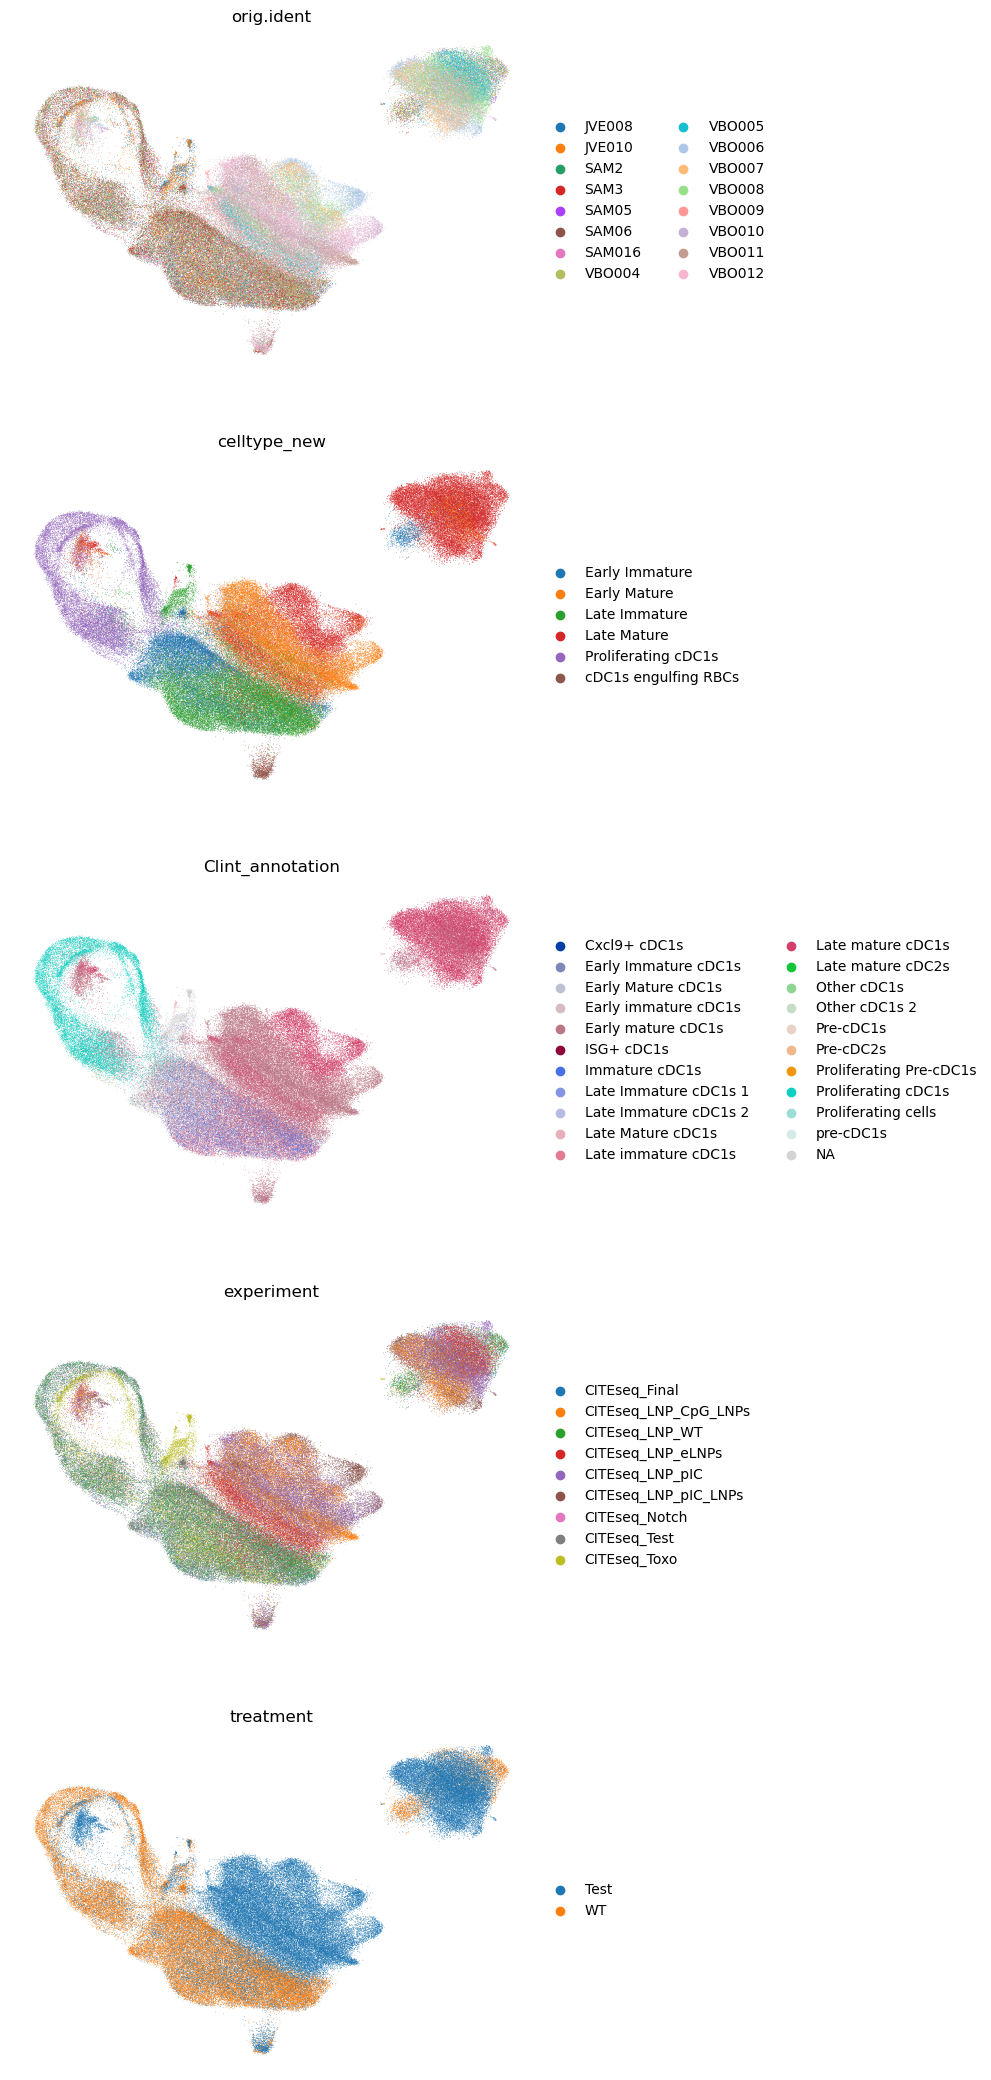

In [16]:
sc.pl.umap(adata,
           color=["orig.ident", "celltype_new", "Clint_annotation", "experiment", "treatment"],
           frameon=False,
           ncols=1)

Make Clint_annotation_v2 for the improved, collapsed annotation.

- pre-cDC1s --> Early immature
- All proliferating --> Proliferating cDC1s
- pre-cDC2s --> early Immature
- late mature cDC2 --> late mature cDC1s
- ISG+ and Cxcl9 --> early mature

In [ ]:
mapping = {
    # Early Immature
    "Early Immature cDC1s": "Early Immature",
    "Early immature cDC1s": "Early Immature",
    "pre-cDC1s": "Early Immature",
    "Pre-cDC1s": "Early Immature",
    "pre-cDC2s": "Early Immature",
    
    # Proliferating
    "Proliferating cDC1s": "Proliferating cDC1s",
    "Proliferating Pre-cDC1s": "Proliferating cDC1s",
    "Proliferating cells": "Proliferating cDC1s",
    
    # Late Mature
    "Late Mature cDC1s": "Late Mature",
    "Late mature cDC1s": "Late Mature",
    "Late mature cDC2s": "Late Mature",
    
    # Late Immature
    "Late Immature cDC1s 1": "Late Immature",
    "Late Immature cDC1s 2": "Late Immature",
    "Late immature cDC1s": "Late Immature",
    
    # Early Mature
    "Early Mature cDC1s": "Early Mature",
    "Early mature cDC1s": "Early Mature",
    "ISG+ cDC1s": "Early Mature",
    "Cxcl9+ cDC1s": "Early Mature",
    
    # cDC1s engulfing RBCs
    "cDC1s engulfing RBCs": "cDC1s engulfing RBCs",
    
    # Other
    "Other cDC1s": "Other cDC1s",
    "Other cDC1s 2": "Other cDC1s",
    "Immature cDC1s": "Immature" # wrong, should be 
}

adata.obs["Clint_annotation_v2"] = (
    adata.obs["Clint_annotation"]
    .map(mapping)
)

# Check result
adata.obs["Clint_annotation_v2"].value_counts(dropna=False)

Clint_annotation_v2
Late Mature            46693
Early Mature           36059
Late Immature          26598
Proliferating cDC1s    14285
Early Immature          9375
NaN                     3986
Other cDC1s               66
Name: count, dtype: int64

In [28]:
adata

AnnData object with n_obs × n_vars = 137062 × 36048
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'RNA_snn_res.0.5', 'seurat_clusters', 'RNA_snn_res.0.6', 'RNA_snn_res.0.7', 'RNA_snn_res.0.8', 'RNA_snn_res.0.9', 'RNA_snn_res.1', 'RNA_snn_res.1.1', 'RNA_snn_res.1.2', 'RNA_snn_res.1.3', 'RNA_snn_res.1.4', 'RNA_snn_res.1.5', 'nCount_ADT', 'nFeature_ADT', 'sctype_classification', 'scDblFinder_class', 'scDblFinder_score', 'percent.mt', 'nCount_HTO', 'nFeature_HTO', 'MULTI_ID', 'MULTI_classification', 'barcodes', 'HTO_Results', 'DF_Results', 'HTO_GUESS', 'MULTI_ID_merge', 'LENIENT_GUESS_merge', 'Annotation_VBO', 'experiment', 'treatment', 'tech', 'ADT_snn_res.1.2', 'RNA.weight', 'ADT.weight', 'wsnn_res.1', 'celltype_new', 'Clint_annotation', 'Clint_annotation_v2'
    var: 'vf_vst_counts.1.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject_mea

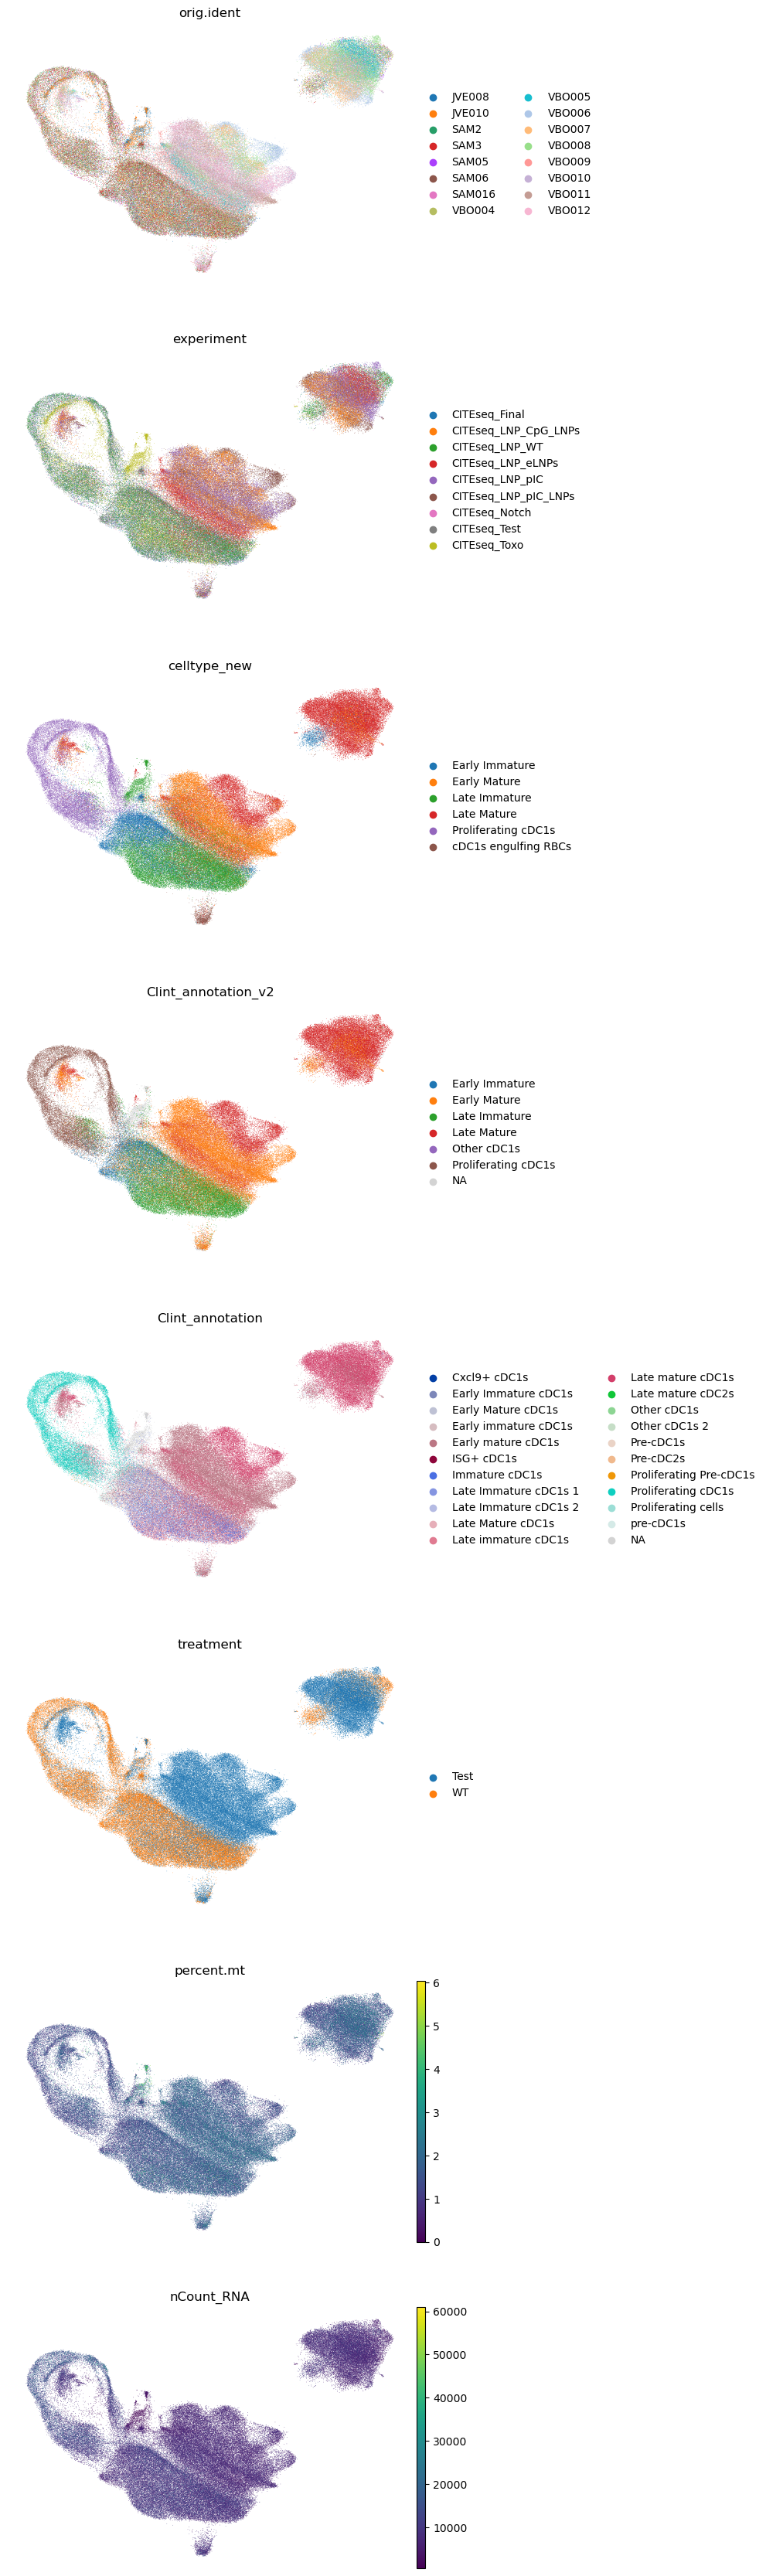

In [31]:
sc.pl.umap(adata,
           color=["orig.ident", "experiment", "celltype_new", "Clint_annotation_v2", "Clint_annotation", "treatment", "percent.mt", "nCount_RNA"],
           frameon=False,
           ncols=1)

Now, we can compare Samuel's annotation to Clint's, using UMAP, Sankey plot and maybe a heatmap. 

In [27]:
COL_RIGHT = "Clint_annotation_v2"
COL_LEFT = "celltype_new"
INCLUDE_MISSING = False   # if True, cells with NaN in either column get
                           # bucketed into a "Not annotated" node instead
                           # of being dropped
MIN_LINK_SIZE = 0         # hide flows smaller than this many cells (0 = show all)
 
 
def build_sankey(adata, col_left, col_right, include_missing=False, min_link_size=0):
    df = adata.obs[[col_left, col_right]].copy()
    df[col_left] = df[col_left].astype(object)
    df[col_right] = df[col_right].astype(object)
 
    if include_missing:
        df[col_left] = df[col_left].fillna("Not annotated")
        df[col_right] = df[col_right].fillna("Not annotated")
    else:
        n_before = len(df)
        df = df.dropna(subset=[col_left, col_right])
        n_dropped = n_before - len(df)
        if n_dropped:
            print(f"Dropped {n_dropped} cells missing '{col_left}' or '{col_right}' "
                  f"(set INCLUDE_MISSING=True to keep them as a 'Not annotated' node).")
 
    # counts per (left, right) pair
    counts = df.groupby([col_left, col_right]).size().reset_index(name="n")
    if min_link_size > 0:
        counts = counts[counts["n"] >= min_link_size]
 
    left_labels = sorted(df[col_left].unique().tolist())
    right_labels = sorted(df[col_right].unique().tolist())

    # Separate internal node IDs
    left_ids = [f"left_{x}" for x in left_labels]
    right_ids = [f"right_{x}" for x in right_labels]

    all_ids = left_ids + right_ids
    all_labels = left_labels + right_labels

    label_to_idx = {
        **{f"left_{lab}": i for i, lab in enumerate(left_labels)},
        **{f"right_{lab}": i + len(left_labels) for i, lab in enumerate(right_labels)}
    }
 
    # simple distinct color palette, cycled if more categories than colors
    palette = [
        "#4E79A7", "#F28E2B", "#E15759", "#76B7B2", "#59A14F",
        "#EDC948", "#B07AA1", "#FF9DA7", "#9C755F", "#BAB0AC",
        "#86BCB6", "#D37295", "#FABFD2", "#B6992D", "#499894",
    ]
    node_colors = [palette[i % len(palette)] for i in range(len(all_labels))]
 
    sources = (
        "left_" + counts[col_left]
    ).map(label_to_idx).tolist()

    targets = (
        "right_" + counts[col_right]
    ).map(label_to_idx).tolist()
    values = counts["n"].tolist()
 
    # semi-transparent link colors, taken from the source node's color
    def hex_to_rgba(h, alpha=0.4):
        h = h.lstrip("#")
        r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
        return f"rgba({r},{g},{b},{alpha})"
 
    link_colors = [hex_to_rgba(node_colors[s]) for s in sources]
 
    fig = go.Figure(data=[go.Sankey(
        arrangement="fixed",
        node=dict(
            pad=15,
            thickness=18,
            line=dict(color="black", width=0.5),
            label=all_labels,
            color=node_colors,
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=link_colors,
        ),
    )])
 
    fig.update_layout(
        title_text=f"{col_left}  →  {col_right}",
        font_size=12,
        width=1100,
        height=max(500, 25 * max(len(left_labels), len(right_labels))),
    )
    return fig
 
 
if __name__ == "__main__":
    fig = build_sankey(adata, COL_LEFT, COL_RIGHT, INCLUDE_MISSING, MIN_LINK_SIZE)
    fig.write_html("sankey_clint_vs_celltype_new.html")
    fig.show()


Dropped 3986 cells missing 'celltype_new' or 'Clint_annotation_v2' (set INCLUDE_MISSING=True to keep them as a 'Not annotated' node).


Now, we copy the scANVI annotation to this object too

In [ ]:
adata_scanvi = sc.read_h5ad("c:/Users/irc/Desktop/Internship Bioinformatics 2025-2026/Lode/scANVI_annotation/scANVI_annotation.h5ad")

In [ ]:
adata = adata_scanvi = sc.read_h5ad("c:/Users/irc/Desktop/Internship Bioinformatics 2025-2026/Lode/Annotation_Comparison/Clint-Samuel_annotation.h5ad")

In [35]:
adata_scanvi

AnnData object with n_obs × n_vars = 137062 × 4000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'RNA_snn_res.0.5', 'seurat_clusters', 'RNA_snn_res.0.6', 'RNA_snn_res.0.7', 'RNA_snn_res.0.8', 'RNA_snn_res.0.9', 'RNA_snn_res.1', 'RNA_snn_res.1.1', 'RNA_snn_res.1.2', 'RNA_snn_res.1.3', 'RNA_snn_res.1.4', 'RNA_snn_res.1.5', 'nCount_ADT', 'nFeature_ADT', 'sctype_classification', 'scDblFinder_class', 'scDblFinder_score', 'percent.mt', 'nCount_HTO', 'nFeature_HTO', 'MULTI_ID', 'MULTI_classification', 'barcodes', 'HTO_Results', 'DF_Results', 'HTO_GUESS', 'MULTI_ID_merge', 'LENIENT_GUESS_merge', 'Annotation_VBO', 'experiment', 'treatment', 'tech', 'ADT_snn_res.1.2', 'RNA.weight', 'ADT.weight', 'wsnn_res.1', 'celltype_new', 'Clint_annotation', 'Clint_annotation_v2', 'scanvi_labels_before', '_scvi_batch', '_scvi_labels', 'scanvi_predicted', 'scanvi_confidence', 'leiden_1_scANVI'
    var: 'vf_vst_counts.1.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.S

In [37]:
adata.obsm["X_scANVI"] = adata_scanvi.obsm["X_scANVI"]
adata.obs["scanvi_predicted"] = adata_scanvi.obs["scanvi_predicted"]
adata.obs["scanvi_confidence"] = adata_scanvi.obs["scanvi_confidence"]
adata.obsm["X_scANVI_umap"] = adata_scanvi.obsm["X_umap"]


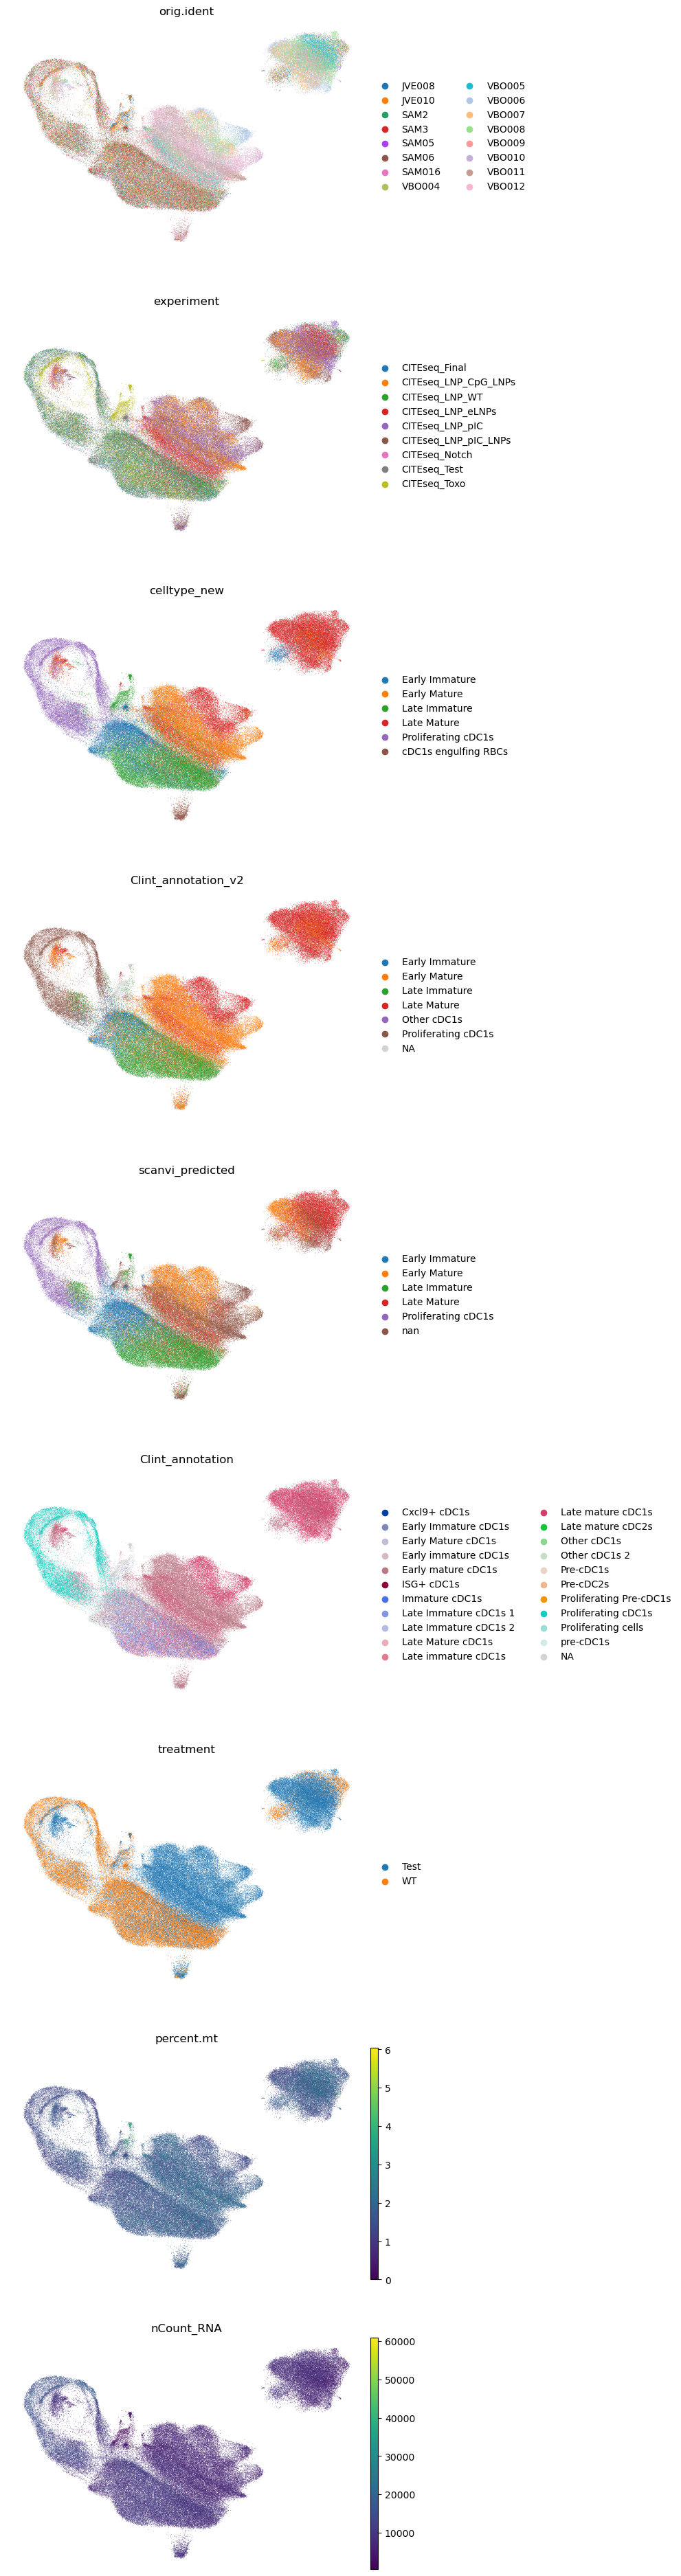

In [8]:
sc.pl.umap(adata,
           color=["orig.ident", "experiment", "celltype_new", "Clint_annotation_v2", "scanvi_predicted", "Clint_annotation", "treatment", "percent.mt", "nCount_RNA"],
           frameon=False,
           ncols=1)

Now, we will use the UMAP of Samuel

In [51]:
adata_samuel = sc.read_h5ad("C:/Users/irc/Desktop/Internship Bioinformatics 2025-2026/Lode/Harmony/Harmony_AnndataR_conversion/data/Harmony_RNA_Samuel_anndataR.h5ad")

In [52]:
adata_samuel

AnnData object with n_obs × n_vars = 137062 × 36048
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'RNA_snn_res.0.5', 'seurat_clusters', 'RNA_snn_res.0.6', 'RNA_snn_res.0.7', 'RNA_snn_res.0.8', 'RNA_snn_res.0.9', 'RNA_snn_res.1', 'RNA_snn_res.1.1', 'RNA_snn_res.1.2', 'RNA_snn_res.1.3', 'RNA_snn_res.1.4', 'RNA_snn_res.1.5', 'nCount_ADT', 'nFeature_ADT', 'sctype_classification', 'scDblFinder_class', 'scDblFinder_score', 'percent.mt', 'nCount_HTO', 'nFeature_HTO', 'MULTI_ID', 'MULTI_classification', 'barcodes', 'HTO_Results', 'DF_Results', 'HTO_GUESS', 'MULTI_ID_merge', 'LENIENT_GUESS_merge', 'Annotation_VBO', 'experiment', 'treatment'
    var: 'vf_vst_counts.1.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject_mean', 'vf_vst_counts.1.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratPro

In [58]:
adata.obsm["RNA_harmony_umap_samuel"] = adata_samuel.obsm["RNA_harmony_umap"]
adata.obsm["RNA_harmony_samuel"] = adata_samuel.obsm["RNA_harmony"]

In [55]:
adata.obsm["X_umap"] = adata.obsm["RNA_harmony_umap_samuel"]

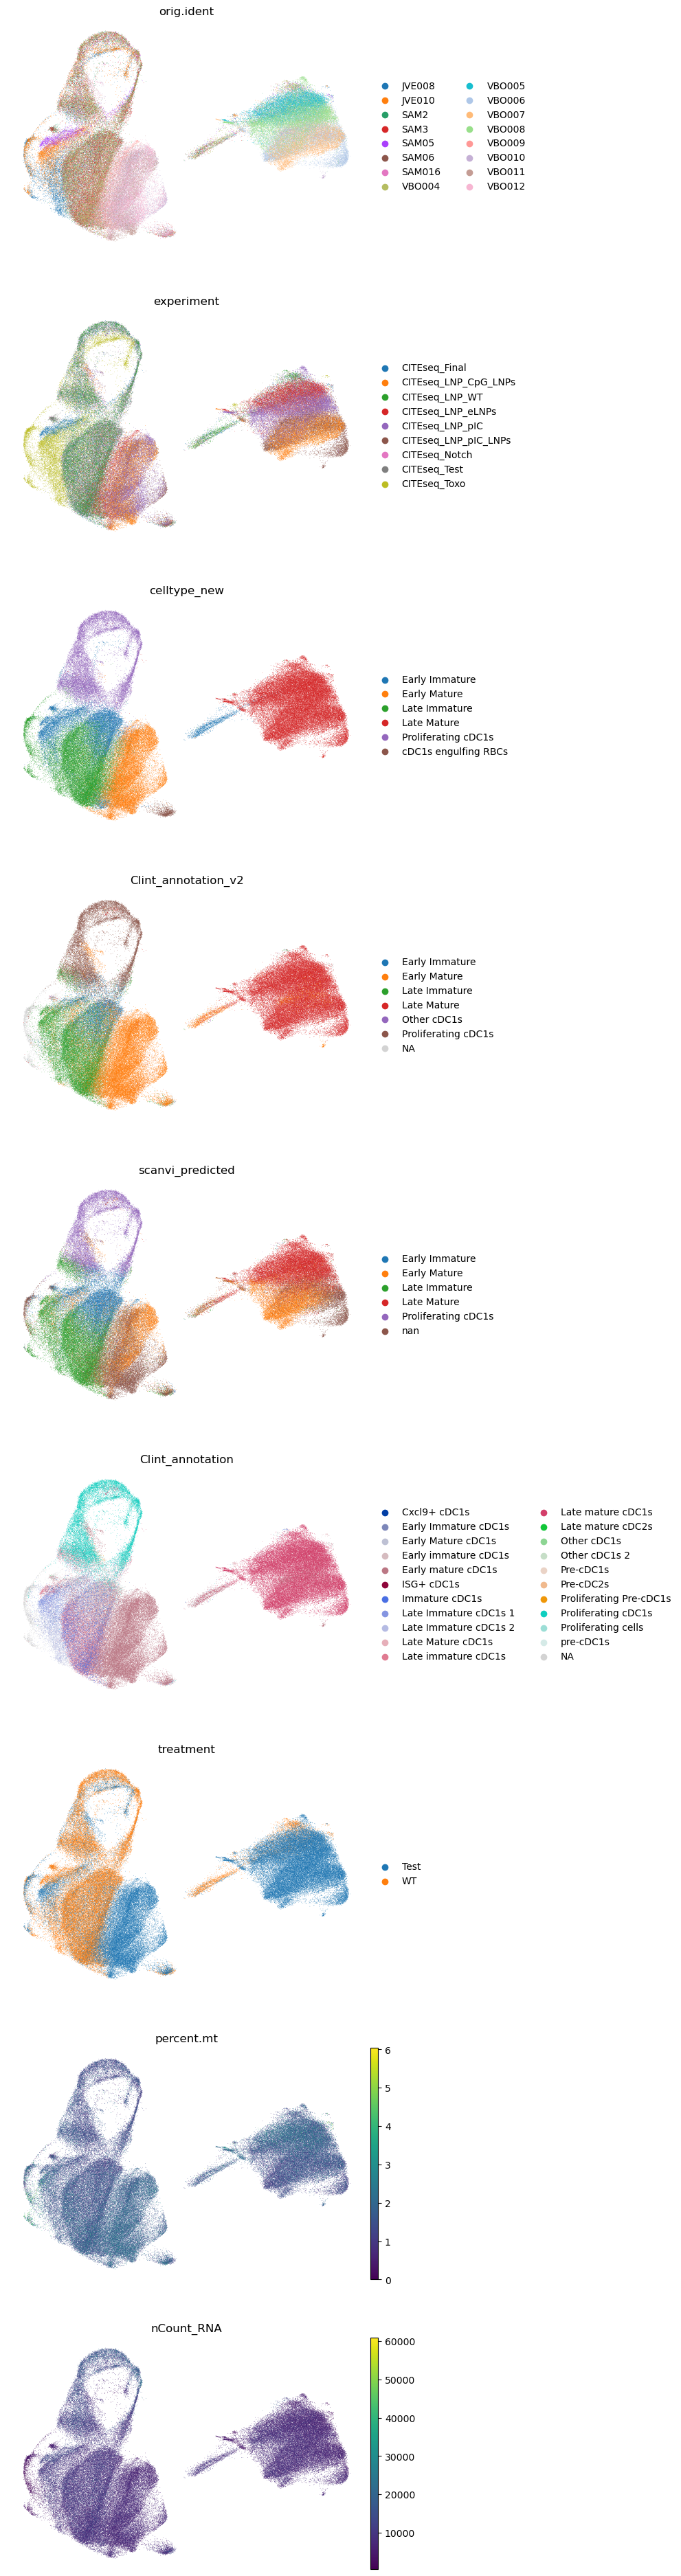

In [56]:
sc.pl.umap(adata,
           color=["orig.ident", "experiment", "celltype_new", "Clint_annotation_v2", "scanvi_predicted", "Clint_annotation", "treatment", "percent.mt", "nCount_RNA"],
           frameon=False,
           ncols=1)

Make dotplots of the individual clusters

In [21]:
markers = {
    "Pre_cDC1": ["Ccr2", "Fcer1g", "Cd24a", "Vim"],
    "Early_Immature": ["Sell", "Creld2", "Pdia4"],
    "Late_Immature": ["Cd207", "Itgae", "Apol7c", "Apoe", "Dnase1l3", "Cadm1", "Xcr1", "Cd83", "Cd86"],
    "Early_Mature": ["Cxcl10", "Cxcl9", "Iigp1", "Ifi47", "Gbp2", "Gbp5", "Cd40"],
    "Late_Mature": ["Cd63", "Fscn1", "Il4i1", "Socs2", "Ccr7"]
}

In [22]:
marker_genes_in_data = {}
for ct, markers in markers.items():
    markers_found = []
    for marker in markers:
        if marker in adata.var.index:
            markers_found.append(marker)
    marker_genes_in_data[ct] = markers_found

In [23]:
adata

AnnData object with n_obs × n_vars = 137062 × 36048
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'RNA_snn_res.0.5', 'seurat_clusters', 'RNA_snn_res.0.6', 'RNA_snn_res.0.7', 'RNA_snn_res.0.8', 'RNA_snn_res.0.9', 'RNA_snn_res.1', 'RNA_snn_res.1.1', 'RNA_snn_res.1.2', 'RNA_snn_res.1.3', 'RNA_snn_res.1.4', 'RNA_snn_res.1.5', 'nCount_ADT', 'nFeature_ADT', 'sctype_classification', 'scDblFinder_class', 'scDblFinder_score', 'percent.mt', 'nCount_HTO', 'nFeature_HTO', 'MULTI_ID', 'MULTI_classification', 'barcodes', 'HTO_Results', 'DF_Results', 'HTO_GUESS', 'MULTI_ID_merge', 'LENIENT_GUESS_merge', 'Annotation_VBO', 'experiment', 'treatment', 'tech', 'ADT_snn_res.1.2', 'RNA.weight', 'ADT.weight', 'wsnn_res.1', 'celltype_new', 'Clint_annotation', 'Clint_annotation_v2', 'scanvi_predicted', 'scanvi_confidence'
    var: 'vf_vst_counts.1.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.SeuratProject.Seur

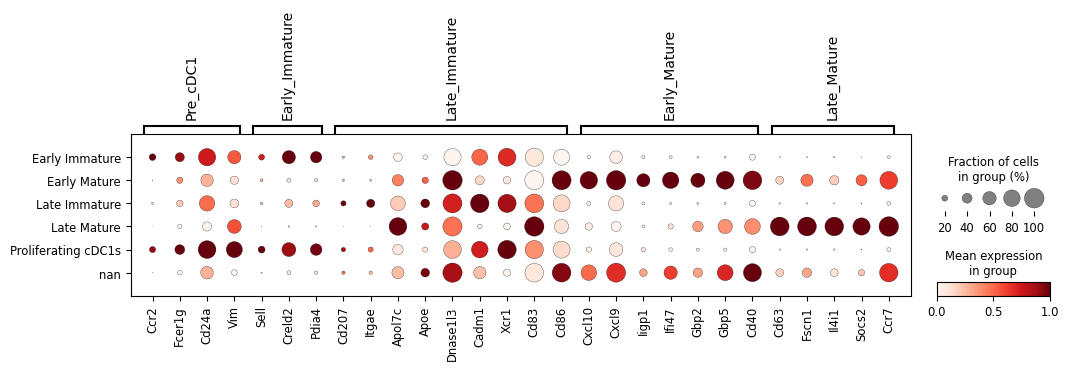

In [ ]:
sc.pl.dotplot(
    adata,
    groupby="",
    var_names=marker_genes_in_data,
    standard_scale="var",  # standard scale: normalize each gene to range from 0 to 1
)

In [38]:
adata.obsm["X_umap"] = adata.obsm["X_scANVI_umap"]

In [ ]:
sc.pl.umap(adata,
           color=["Ccr2","Cadm1", "Xcr1","Cd86","Cxcl10","Cxcl9","Cd63","Fscn1","Ccr7"],
           frameon=False,
           vmin=0, # put scale so it does not inflate, clip at 90 th percentile
           vmax=5,
           ncols=3)

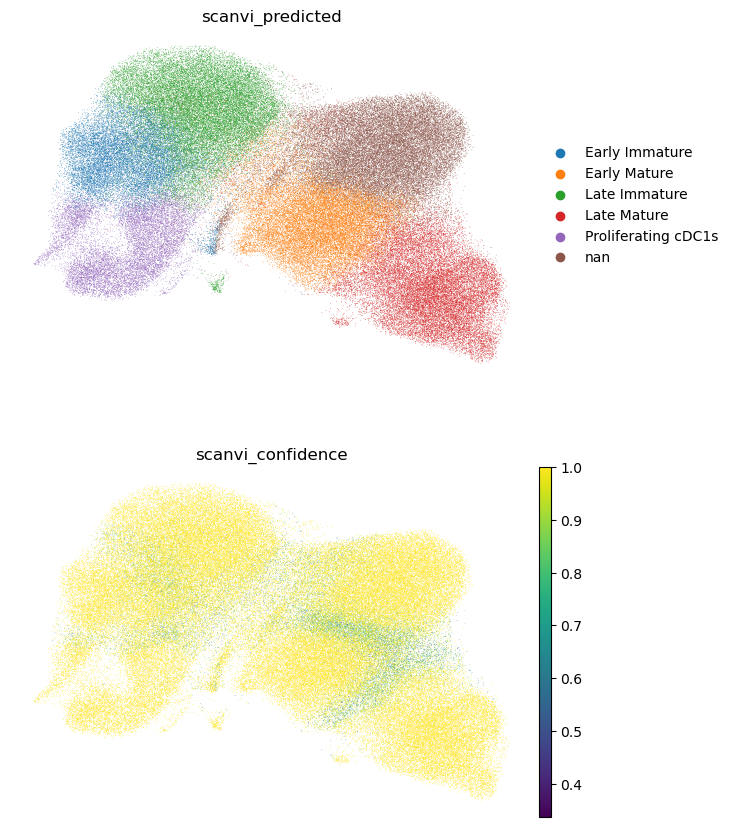

In [49]:
sc.pl.umap(adata,
           color=["scanvi_predicted", "scanvi_confidence"],
           frameon=False,
           ncols=1)

In [ ]:
adata.obs["scanvi_predicted"].value_counts()
# lots of cells have gotten no label, this NA comes from the sample supplied to scANVI (SAM3)

scanvi_predicted
nan                    32503
Late Immature          27420
Early Mature           24772
Late Mature            24478
Early Immature         15156
Proliferating cDC1s    12733
Name: count, dtype: int64

In [ ]:
adata.obs["scanvi_predicted"].value_counts()
# lots of cells have gotten no label

In [50]:
adata.obs.loc[
    adata.obs["orig.ident"] == "SAM3",
    "scanvi_predicted"
].value_counts()

scanvi_predicted
Late Immature          4326
Early Immature         3681
Proliferating cDC1s    2234
Early Mature            588
Late Mature             444
nan                     273
Name: count, dtype: int64

DEA

In [ ]:
sc.tl.rank_genes_groups(
    adata, groupby="leiden_1_scANVI", method="wilcoxon", key_added="dea_leiden_1"
)

In [ ]:
sc.tl.dendrogram(
    adata,
    groupby="leiden_1",
)

sc.pl.rank_genes_groups_dotplot(
    adata, groupby="leiden_1_scANVI", standard_scale="var", n_genes=5, key="dea_leiden_1_scANVI"
)

In [59]:
adata.write_h5ad("Clint-Samuel__scANVI_annotation.h5ad")